In [2]:
import math
import numpy as np
from tqdm import tqdm
from utils import load_graph
import matplotlib.pyplot as plt
from scipy.stats import truncnorm
from models import truncnorm_thresholds, apply_thresholds

## Threshold Distributions

We are working with a truncated normal distribution of thresholds, with abscissae [0,1]. We have the issue of nodes with threshold 0 being spontaneously activated, as an activation occurs when a node has n >= threshold activated neighbors. We therefore bind the lower limit of actual thresholds to 1. 

However, we have the caveat that we are dealing with asymptotically scale-free networks, where a majority of nodes likely have a degree of 1. Therefore, our actual distribution of thresholds likely varies from the ideal truncated normal distribution that we apply.

It is therefore relevant to look at the actual distribution of thresholds.

Question: I can look at three things.
* The fractions returned by the truncated normal function
* The actual thresholds           -> likely to see 1 overrepresented
* Actual threshold / degree       -> likely to see 100% overrepresented

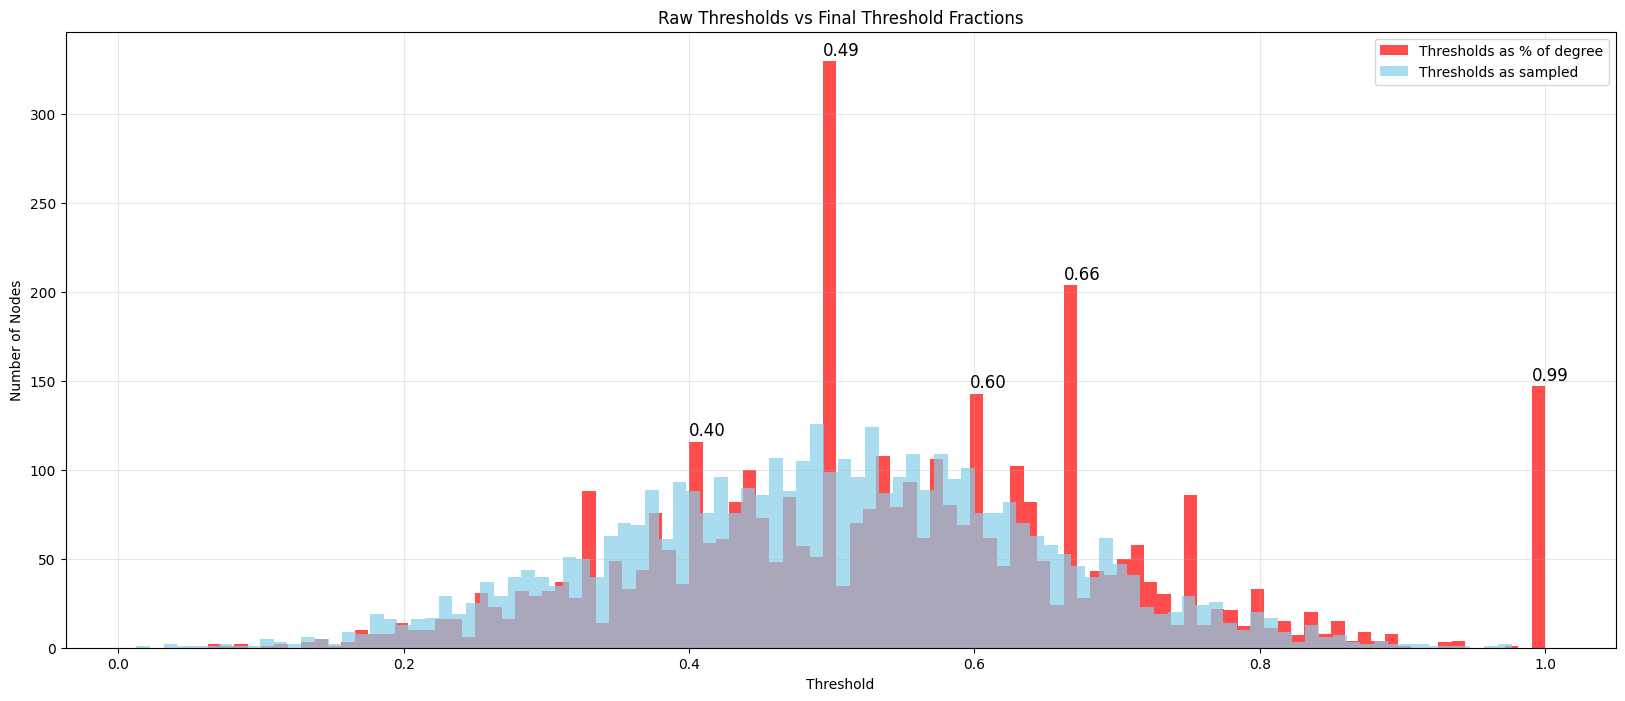

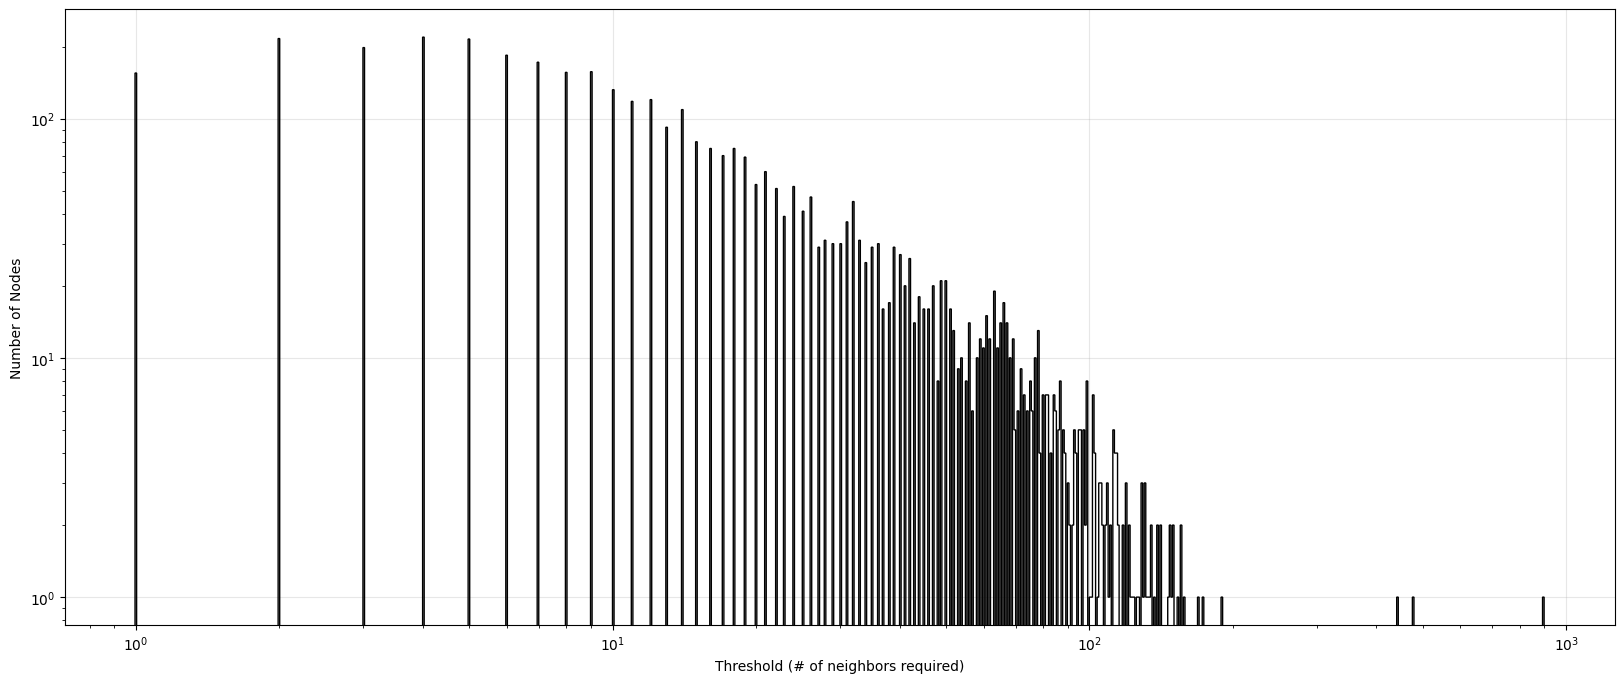

In [3]:
# Data setup
dataset = "datasets/fb.txt"
G = load_graph(dataset)

# Paramaters
mean = 0.5
std = 0.15

# ----- RAW THRESHOLDS -----
ps = truncnorm_thresholds(len(G.nodes()), mean, std)

# ----- REAL THRESHOLDS -----
thresholds = apply_thresholds(G, ps)

# ----- NORMALIZED THRESHOLDS -----
threshold_fractions = [threshold / G.degree[node] for node, threshold in thresholds.items()]


# ----- PLOTTING -----
plt.figure(figsize=(20, 8))

# Plot normalized threholds
counts, bins, _ = plt.hist(
    threshold_fractions, 
    bins=100, 
    color='red', 
    alpha=0.7, 
    histtype="stepfilled", 
    label="Thresholds as % of degree")

# Plot raw thresholds
plt.hist(
    ps, 
    bins=100, 
    color='skyblue', 
    alpha=0.7, 
    histtype="stepfilled", 
    label="Thresholds as sampled")


# ----- LABEL MOST COMMON THRESHOLDS -----
top5_indices = np.argsort(counts)[-5:]              # Indices of top 5 counts
top5_values = np.array(bins)[top5_indices]      # 5 tallest bins

# Add labels to tallest bins
for val in top5_values:
    bin_index = min(np.digitize(val, bins) - 1, len(counts)-1)
    bin_height = counts[bin_index]
    
    plt.text(val, bin_height + 1, f"{val:.2f}", 
             ha='left', va='bottom', fontsize=12)


# ----- Plot labeling  -----
plt.title("Raw Thresholds vs Final Threshold Fractions")
plt.xlabel("Threshold")
plt.ylabel("Number of Nodes")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()




# Plot actual thresholds
plt.figure(figsize=(20, 8))
hist, bins= np.histogram(list(thresholds.values()), bins=range(1, max(thresholds.values()) + 2))

logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))

plt.hist(thresholds.values(),
         bins=logbins, 
         color='salmon', 
         edgecolor='black', 
         align='left',
         histtype="step")
plt.title("")
plt.xlabel("Threshold (# of neighbors required)")
plt.ylabel("Number of Nodes")
plt.yscale("log")
plt.xscale("log")
plt.grid(True, alpha=0.3)
plt.show()


## Observations

We're actually seeing an overrepresentation of 50% thresholds in the final fractions, but that actually makes sense. Fb is not perfectly scale free and the majority of nodes actually have degree 2. And most of them get threshold = 1.

Interestingly, we're not always seeing the expected spike in the most common actual threshold being 1. 


In the wikipedia set, which is much closer to being scale free and has an extreme majority of nodes with 1 neighbor, we see the expected spike in threshold fraction = 1.